##### This script contains the following:

#### 1. Importing libraries and datasets
#### 2. Data Wrangling
#### 3. Creating Random Forests
#### 4. Feature Importances


### 1. Importing libraries and datasets

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from numpy import argmax

In [4]:
# Defining a path for importing/exporting
path = r'/Users/peterguan/ClimateWins ML'

In [5]:
# Importing the Cleaned Weather Observations dataset
climatewins_cleaned = pd.read_csv(r'/Users/peterguan/ClimateWins ML/Data Sets/climatewins_clean_weather_observations.csv', index_col = False)

In [6]:
# Checking if the dataset was imported successfully 
climatewins_cleaned.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [7]:
# Checking the dimensions
climatewins_cleaned.shape

(22950, 137)

In [8]:
# Importing the PLEASANT WEATHER dataset
pleasantweather = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [9]:
# Checking if the dataset was imported successfully 
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
# Checking the dimensions
pleasantweather.shape

(22950, 16)

### 2. Data Wrangling

#### 2010s

In [13]:
# Filtering Cleaned dataset to 2010s
climatewins_cleaned_2010s = climatewins_cleaned[climatewins_cleaned['DATE'].astype(str).str.startswith('201')] 

In [14]:
# Checking if the filtering was successful 
climatewins_cleaned_2010s.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,1,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
18264,20100102,1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
18265,20100103,1,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
18266,20100104,1,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
18267,20100105,1,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4


In [15]:
# Checking the dimensions
climatewins_cleaned_2010s.shape

(3652, 137)

In [16]:
# Filtering Pleasant dataset to 2010s
pleasantweather_2010s = pleasantweather[pleasantweather['DATE'].astype(str).str.startswith('201')] 

In [17]:
# Checking the dimensions
pleasantweather_2010s.shape

(3652, 16)

In [18]:
# Dropping the 'DATE' and 'MONTH' columns from 2010s Cleaned dataset
climatewins_dropped_2010s = climatewins_cleaned_2010s.drop(columns=['DATE', 'MONTH'])

In [19]:
# Checking the dimensions
climatewins_dropped_2010s.shape

(3652, 135)

In [20]:
# Dropping 'DATE' column from 2010s pleasant dataset
pleasantweather_dropped_2010s = pleasantweather_2010s.drop(columns=['DATE'])

# Checking dimensions
pleasantweather_dropped_2010s.shape

(3652, 15)

In [21]:
# Creating matrices (Combining 15 columns in pleasant weather data into a single column)
y_1 = pleasantweather_dropped_2010s.max(axis=1)
print("Shape of y_1_combined:", y_1.shape)

Shape of y_1_combined: (3652,)


In [22]:
# Checking unique values in y_combined to ensure it is correct
print("Unique values in y_1_combined:", y_1.unique())

Unique values in y_1_combined: [0 1]


In [23]:
# Checking y has the correct shape
y_1 = y_1.to_numpy().reshape(-1)

In [24]:
# Check shape
y_1.shape

(3652,)

In [25]:
# Creating X matrix
X_1 = climatewins_dropped_2010s.to_numpy()

In [26]:
# Checking shapes
print(X_1.shape)
print(y_1.shape)

(3652, 135)
(3652,)


In [27]:
# Split data into training and testing sets

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, random_state=127)

In [28]:
# Checking shapes
print(X_train_1.shape, y_train_1.shape)
print(X_test_1.shape, y_test_1.shape)

(2739, 135) (2739,)
(913, 135) (913,)


#### 2000s

In [30]:
# Filtering weather dataset to 2000s
climatewins_cleaned_2000s = climatewins_cleaned[climatewins_cleaned['DATE'].astype(str).str.startswith('200')] 

In [31]:
# Checking if the filter was successful 
climatewins_cleaned_2000s.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
14610,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,0.7,6,0.89,1.0235,0.22,0.10,0.7,6.6,2.1,11.0
14611,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,2.0,8,0.92,1.0177,0.13,0.42,0.0,9.6,7.3,10.6
14612,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,2.8,4,0.79,1.0154,0.22,1.05,1.2,8.6,7.3,9.9
14613,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,4.6,6,0.76,1.0099,0.36,0.34,3.5,8.1,5.0,7.7
14614,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,2.9,7,0.81,0.9957,0.12,0.33,0.0,7.7,4.0,11.3


In [32]:
# Checking the dimensions
climatewins_cleaned_2000s.shape

(3653, 137)

In [33]:
# Filtering Pleasant dataset to 2000s
pleasantweather_2000s = pleasantweather[pleasantweather['DATE'].astype(str).str.startswith('200')] 

In [34]:
# Checking if the filter was successful 
pleasantweather_2000s.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
14610,20000101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14611,20000102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14612,20000103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14613,20000104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14614,20000105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [35]:
# Checking the dimensions
pleasantweather_2000s.shape

(3653, 16)

In [36]:
# Dropping 'DATE' and 'MONTH' columns from 2000s weather dataset
climatewins_dropped_2000s = climatewins_cleaned_2000s.drop(columns=['DATE', 'MONTH'])

# Checking shape
climatewins_dropped_2000s.shape

(3653, 135)

In [37]:
# Dropping 'DATE' column from 2000s pleasant dataset
pleasantweather_dropped_2000s = pleasantweather_2000s.drop(columns=['DATE'])

# Check shape
pleasantweather_dropped_2000s.shape

(3653, 15)

In [38]:
# Creating matrices (Combining 15 columns in Pleasant weather data into single column)
y_2 = pleasantweather_dropped_2000s.max(axis=1)
print("Shape of y_2_combined:", y_2.shape)

Shape of y_2_combined: (3653,)


In [39]:
# Checking unique values in y_combined to ensure it is correct
print("Unique values in y_2_combined:", y_2.unique())

Unique values in y_2_combined: [0 1]


In [40]:
# Checking if y has the correct shape
y_2 = y_2.to_numpy().reshape(-1)

In [41]:
# Checking shape
y_2.shape

(3653,)

In [42]:
# Creating X matrix
X_2 = climatewins_dropped_2000s.to_numpy()

In [43]:
# Checking shapes
print(X_2.shape)
print(y_2.shape)

(3653, 135)
(3653,)


In [44]:
# Splitting data into training and testing sets

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=127)

In [45]:
# Checking shapes
print(X_train_2.shape, y_train_2.shape)
print(X_test_2.shape, y_test_2.shape)

(2739, 135) (2739,)
(914, 135) (914,)


### 3. Creating Random Forests

#### 2010s

In [48]:
# Creating a Random Forest classifier
clf_1 = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_1.fit(X_train_1, y_train_1)

RandomForestClassifier(max_depth=10)

In [49]:
# Perform the predictions on the test dataset
y_pred_1 = clf_1.predict(X_test_1)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_1, y_pred_1))

Model Accuracy:  0.9802847754654983


In [50]:
# Check unique values in y
unique_classes = np.unique(y_1)
print(unique_classes)
print(len(unique_classes)) 

[0 1]
2


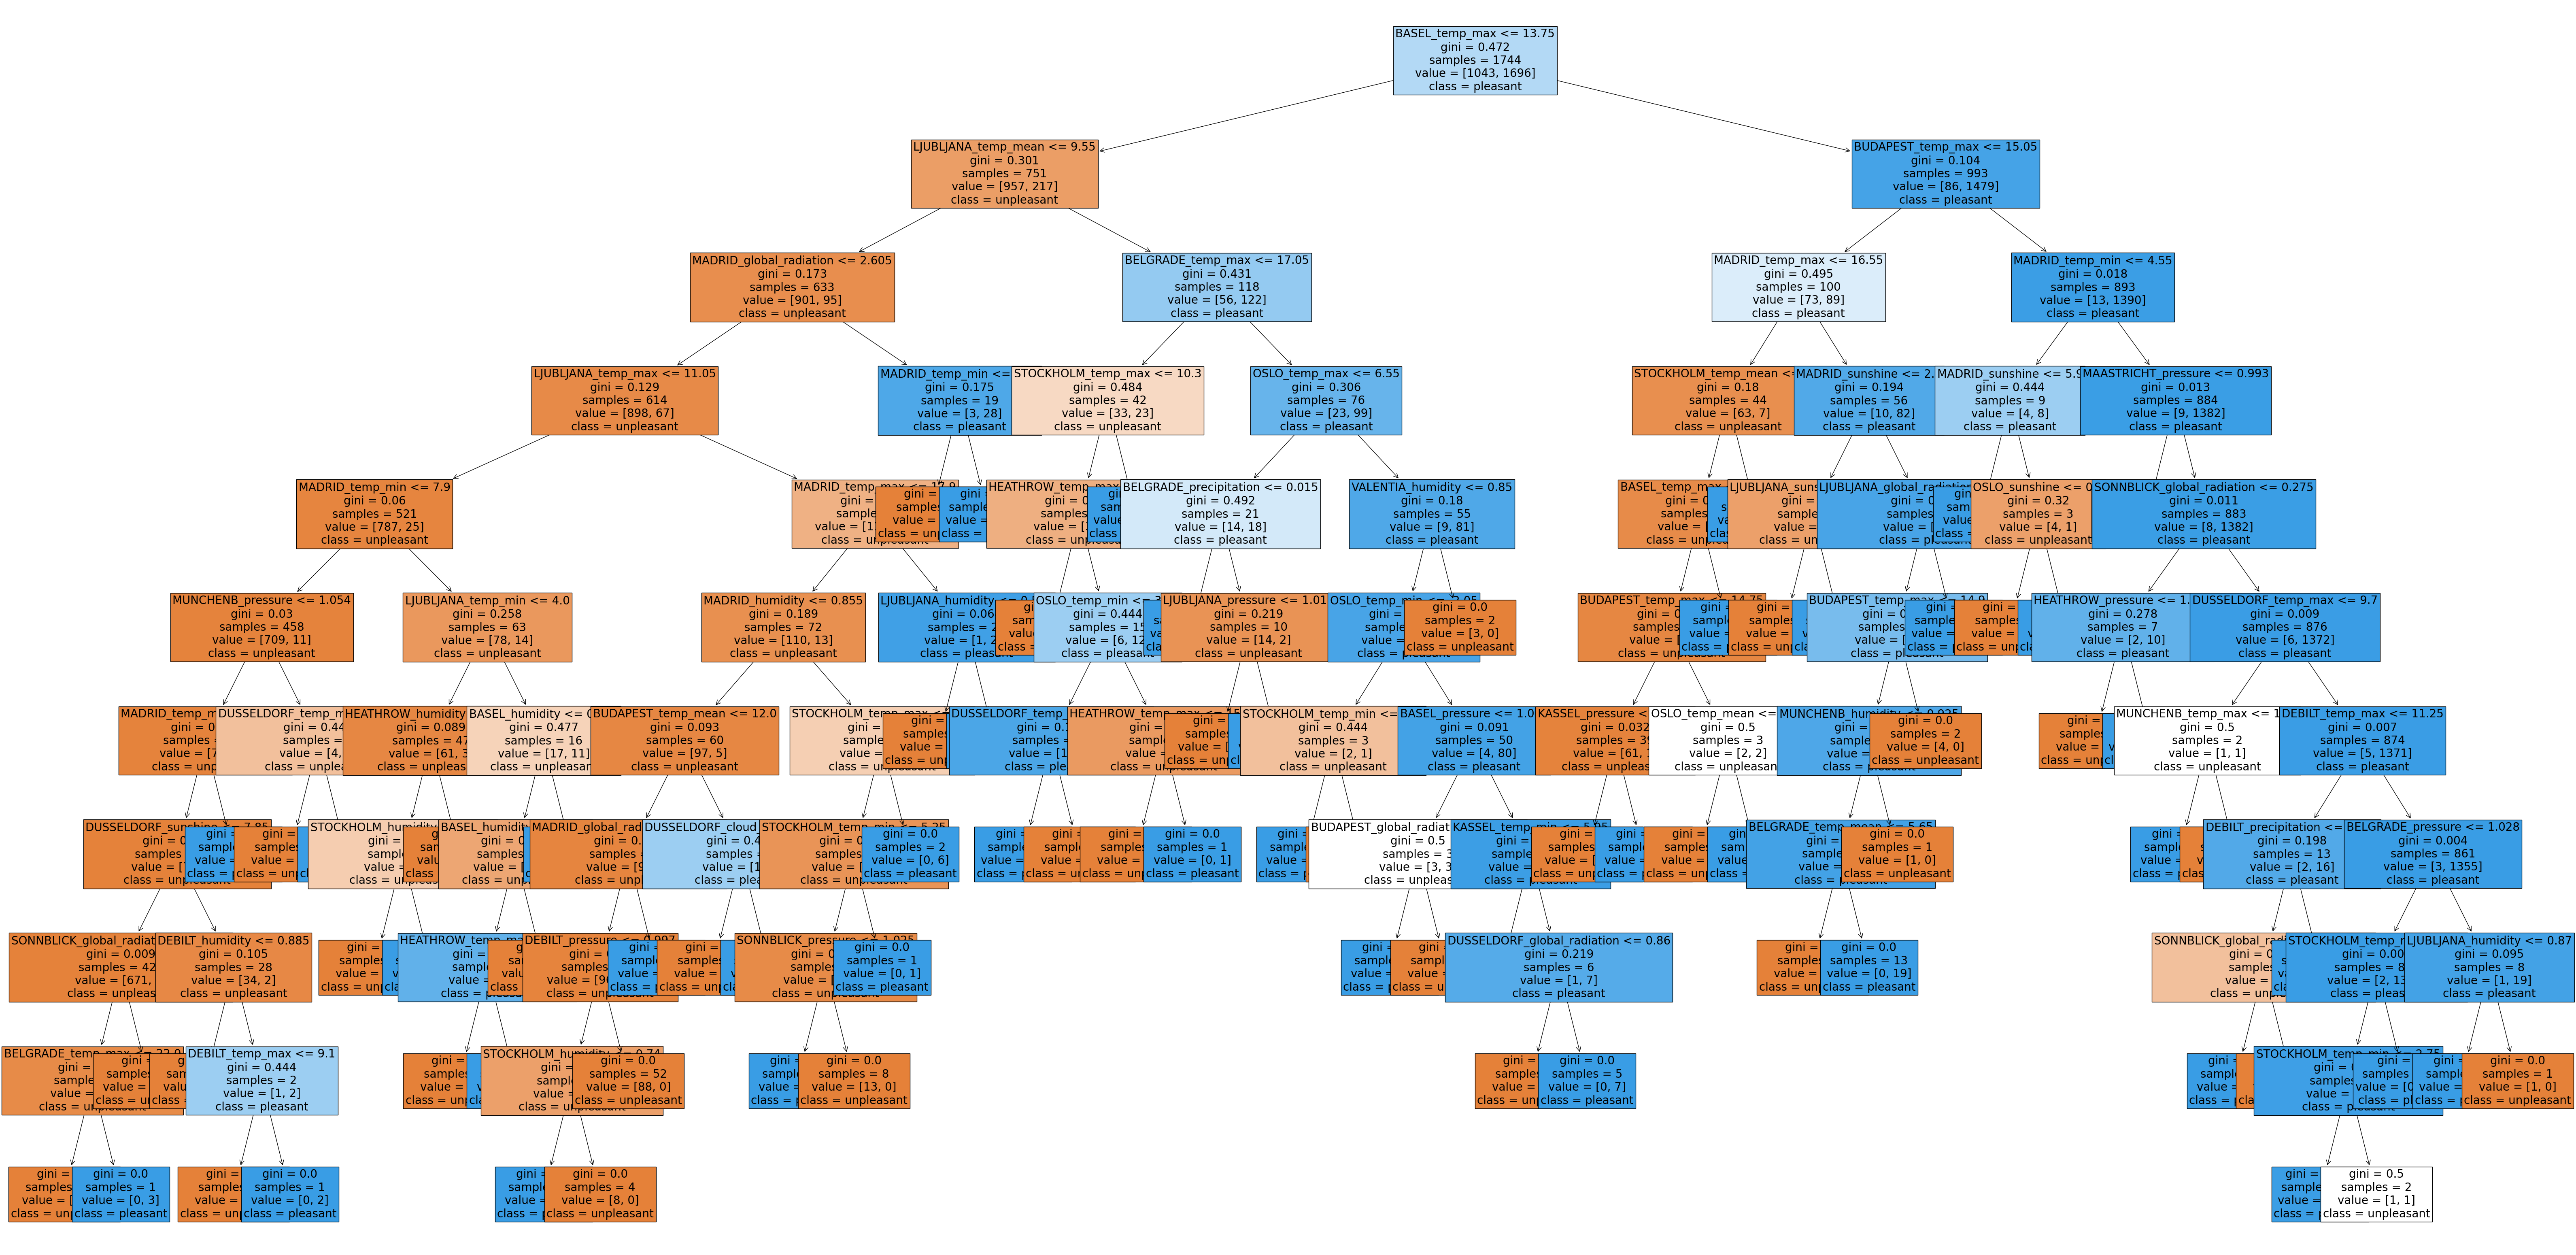

In [51]:
# Plotting the RANDOM FOREST (2010s)
rf_1 = plt.figure(figsize=(80,40))
plot_tree(clf_1.estimators_[5], fontsize = 20, feature_names=climatewins_dropped_2010s.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

#### 2000s

In [53]:
# Creating a Random Forest classifier
clf_2 = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_2.fit(X_train_2, y_train_2)

RandomForestClassifier(max_depth=10)

In [54]:
# Perform the predictions on the test dataset
y_pred_2 = clf_2.predict(X_test_2)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_2, y_pred_2))

Model Accuracy:  0.9638949671772429


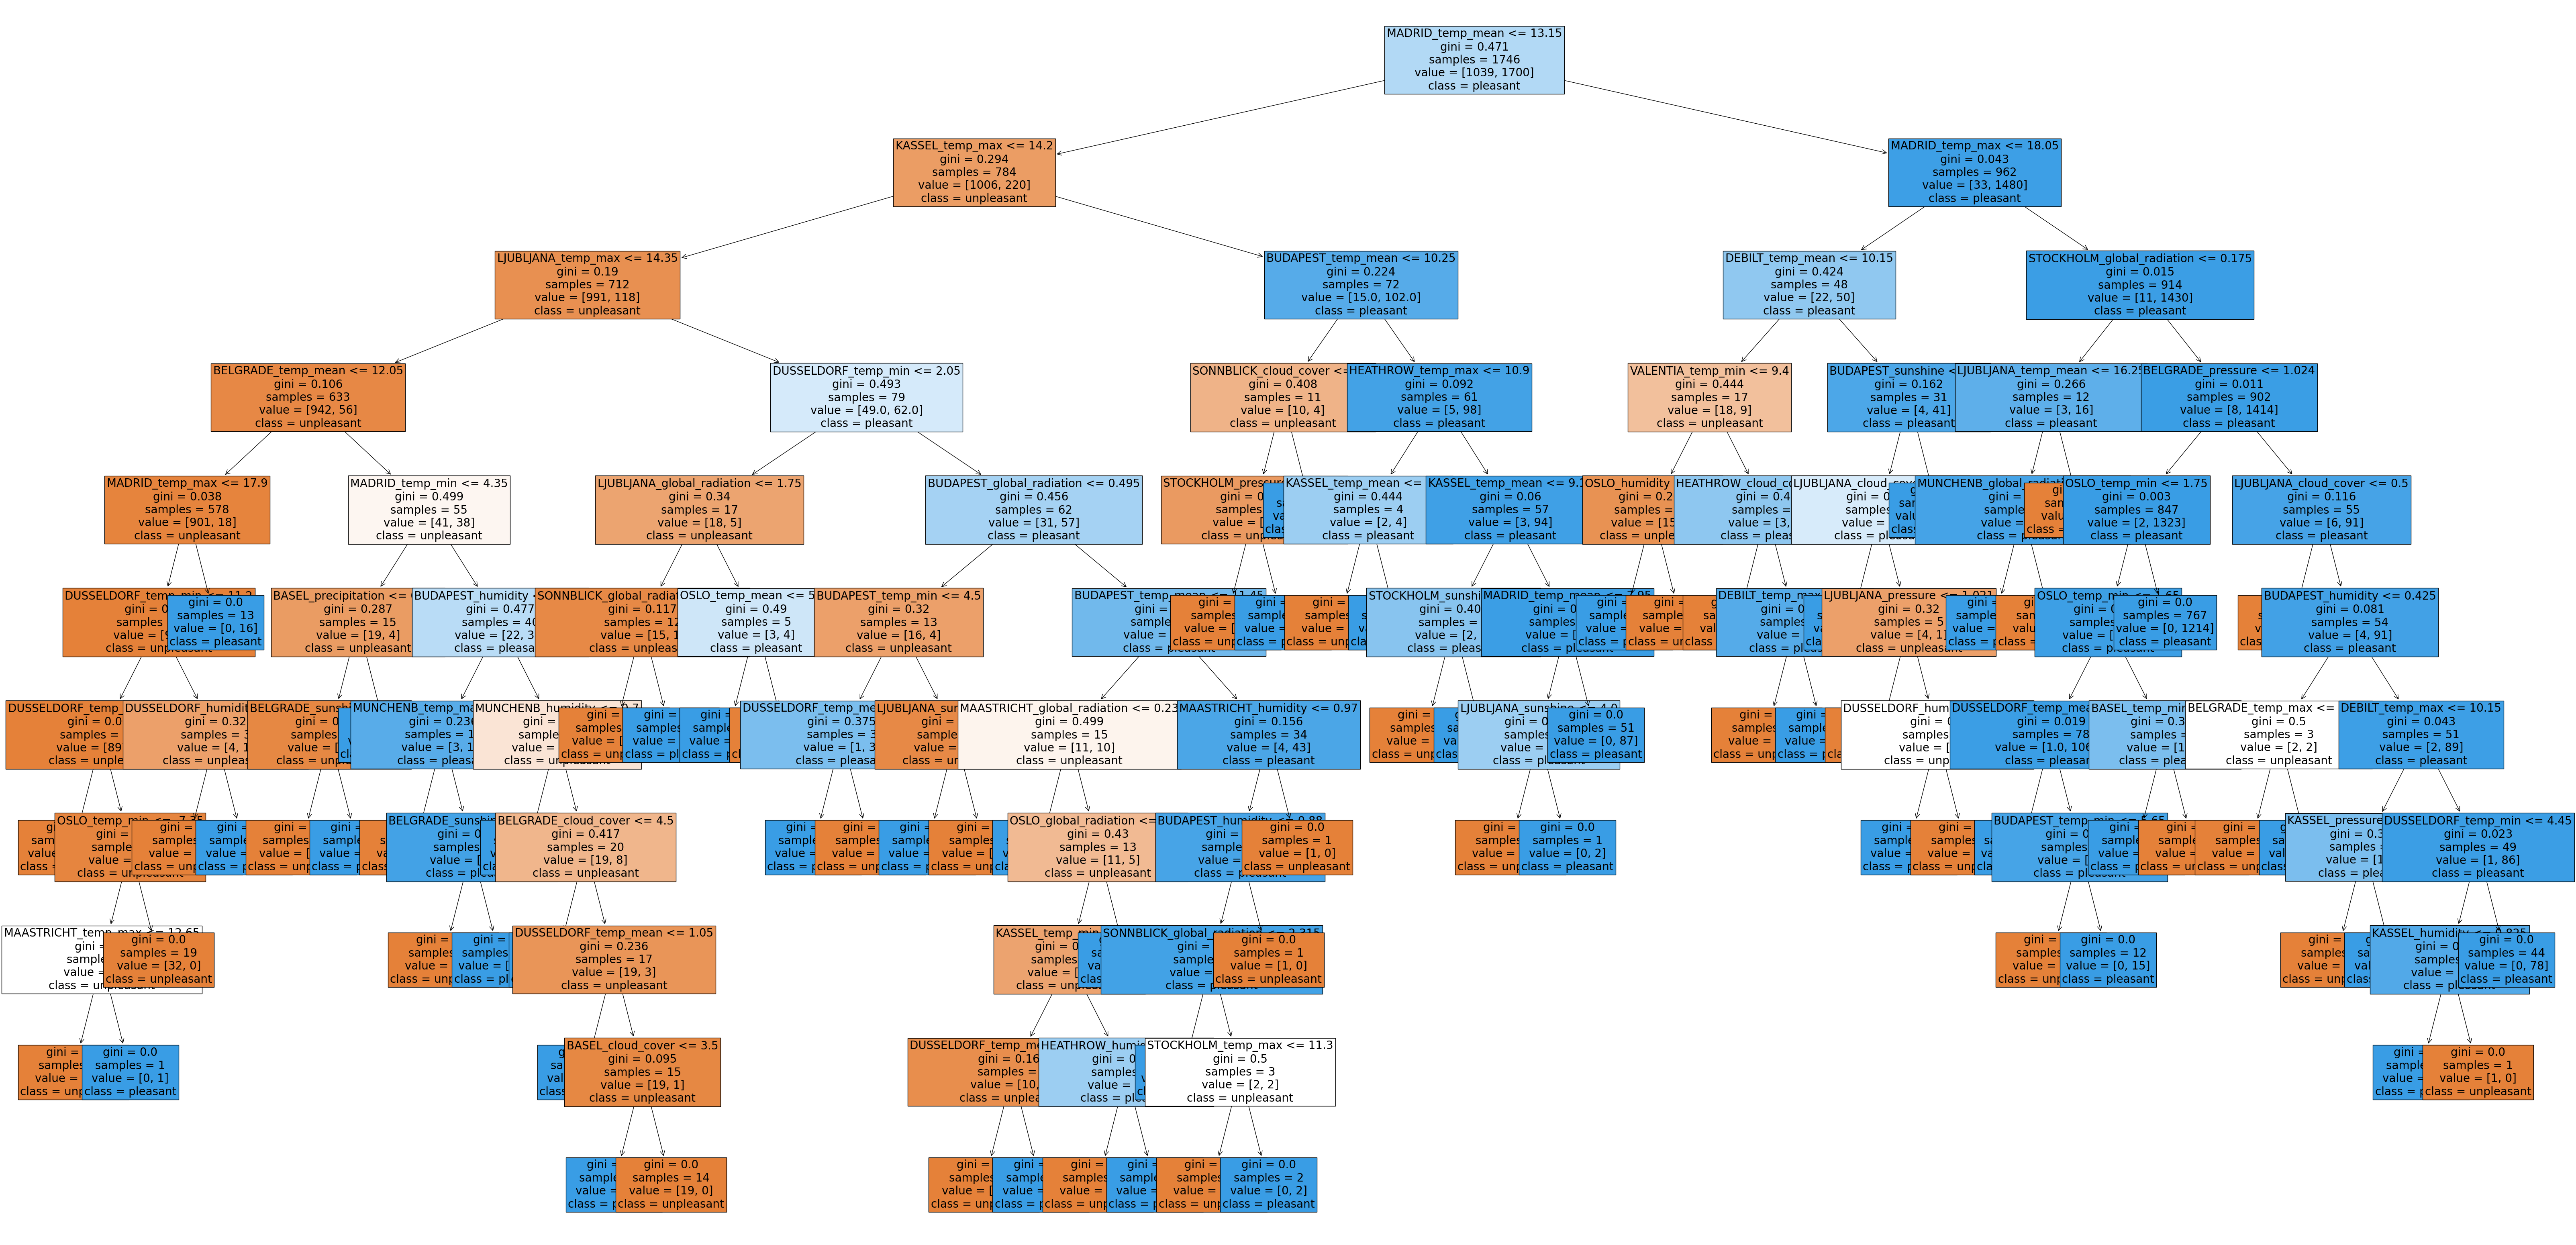

In [55]:
# Plotting a RANDOM FOREST (2000s)
rf_2 = plt.figure(figsize=(80,40))
plot_tree(clf_2.estimators_[5], fontsize = 20, feature_names=climatewins_dropped_2000s.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

### 4. Feature Importances

#### 2010s

In [58]:
# Retrieving feature importances from the trained model
feature_importances_1 = clf_1.feature_importances_
print("Feature Importances:", feature_importances_1)
print(feature_importances_1.shape)

Feature Importances: [3.38086940e-04 8.43849860e-04 1.31608017e-03 3.13691954e-03
 3.57929790e-04 6.16121262e-04 6.22313439e-02 2.33626001e-03
 3.81500060e-02 7.00105623e-04 2.15465224e-03 1.94022149e-03
 1.21154954e-03 2.22239952e-03 1.36319321e-03 2.27178913e-02
 2.66160828e-03 2.42909056e-02 1.59599016e-04 0.00000000e+00
 0.00000000e+00 1.09819573e-03 1.43403788e-03 1.20395019e-03
 2.98101259e-02 2.12579435e-02 4.62832839e-02 3.93768530e-04
 1.32356204e-03 1.01441198e-03 2.96153612e-03 5.46387926e-04
 8.51061913e-04 9.38656571e-03 1.41738738e-03 3.78423952e-02
 3.65111303e-04 8.33042158e-04 1.18390531e-03 1.81980723e-03
 4.47408650e-04 5.53419827e-04 9.69313968e-03 1.80868470e-03
 4.94237577e-02 3.67884396e-04 8.96191199e-04 1.20567724e-03
 3.70511255e-03 5.19132107e-04 2.77033386e-03 2.01465732e-02
 8.89438373e-04 4.91382098e-03 6.66891645e-04 2.87854786e-04
 6.40967145e-04 5.11923512e-04 2.95758835e-04 3.88382158e-04
 4.11454314e-04 6.96872856e-04 9.64626542e-04 5.86252573e-04
 2.

In [59]:
# Reshape the feature importances to (-1, 15, 9)
reshaped_importances_1 = feature_importances_1.reshape(-1, 15, 9)

# Check shape
print("Reshaped Importances Shape:", reshaped_importances_1.shape)

Reshaped Importances Shape: (1, 15, 9)


In [60]:
# Sum the values across the last dimension to get one observation for each weather station
collapsed_importances_1 = np.sum(reshaped_importances_1[0], axis=1)

# Check shape
print("Collapsed Importances Shape:", collapsed_importances_1.shape)
print("Collapsed Importances:", collapsed_importances_1)

Collapsed Importances Shape: (15,)
Collapsed Importances: [0.1093266  0.05926253 0.10124714 0.05573708 0.06612828 0.03541416
 0.00486473 0.1126027  0.05202909 0.18680356 0.09138985 0.05176038
 0.02339718 0.04648619 0.00355055]


In [61]:
# Create list for weather stations
weather_stations = ['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF', 
                    'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID', 
                    'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']

In [62]:
# Create a dataframe to associate weather stations with their importances
collapsed_importances_df_1 = pd.DataFrame({
    'Weather Station': weather_stations,
    'Importance': collapsed_importances_1
})

In [63]:
# Sort by importance for chart readability
collapsed_importances_df_1 = collapsed_importances_df_1.sort_values(by='Importance', ascending=False)
print("Collapsed Feature Importances:")
print(collapsed_importances_df_1)

Collapsed Feature Importances:
   Weather Station  Importance
9           MADRID    0.186804
7        LJUBLJANA    0.112603
0            BASEL    0.109327
2         BUDAPEST    0.101247
10        MUNCHENB    0.091390
4       DUSSELDORF    0.066128
1         BELGRADE    0.059263
3           DEBILT    0.055737
8       MAASTRICHT    0.052029
11            OSLO    0.051760
13       STOCKHOLM    0.046486
5         HEATHROW    0.035414
12       SONNBLICK    0.023397
6           KASSEL    0.004865
14        VALENTIA    0.003551


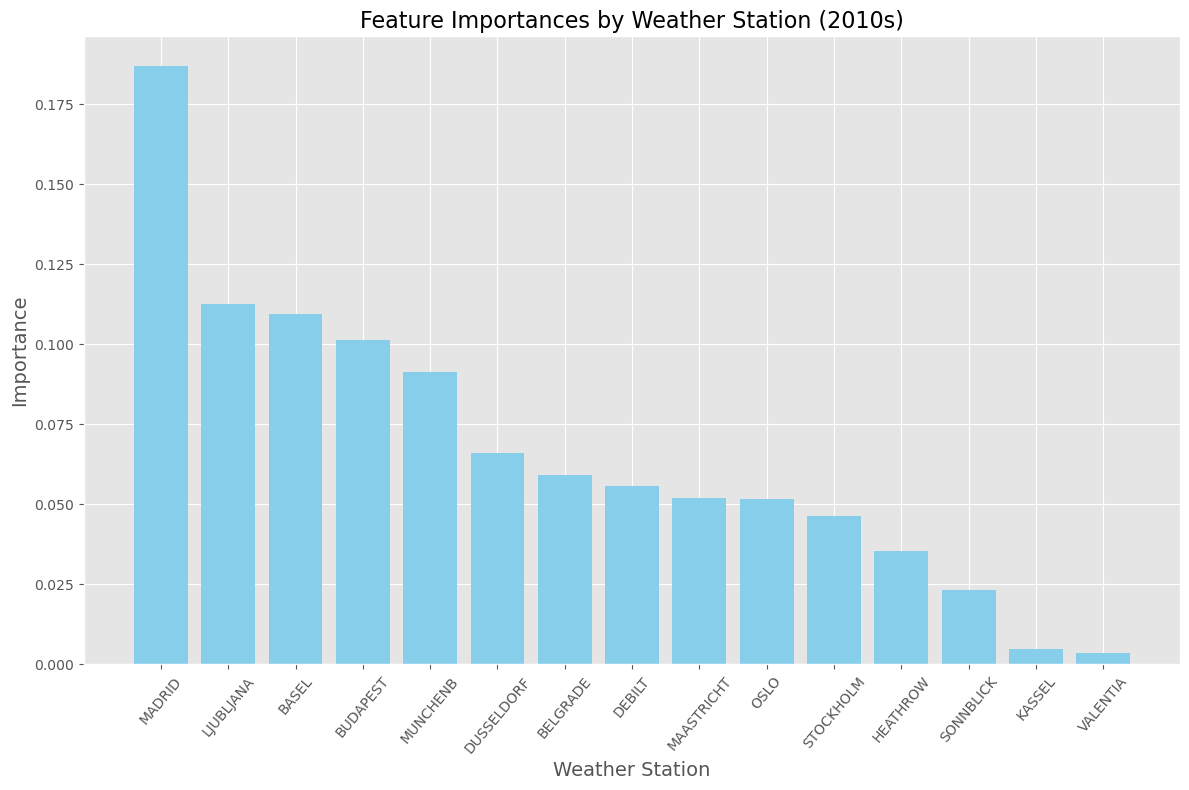

In [64]:
# Plotting the importances

plt.style.use('ggplot')
plt_1 = plt.figure(figsize=(12, 8))
plt.bar(collapsed_importances_df_1['Weather Station'], collapsed_importances_df_1['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Weather Station', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Feature Importances by Weather Station (2010s)', fontsize=16)
plt.tight_layout()
plt.show()

#### 2000s

In [66]:
# Retrieve feature importances from the trained model
feature_importances_2 = clf_2.feature_importances_
print("Feature Importances:", feature_importances_2)

Feature Importances: [0.00052953 0.0014699  0.00124606 0.00131086 0.00084968 0.00086823
 0.0372462  0.0022587  0.01743747 0.00119439 0.0031875  0.00151495
 0.01315823 0.00250136 0.00289226 0.03605499 0.00311107 0.03202294
 0.00071039 0.00173538 0.00131445 0.00468082 0.00113168 0.00211223
 0.03098189 0.01360703 0.05073622 0.00056957 0.00093838 0.0008418
 0.00446645 0.00054545 0.00072712 0.00129151 0.00203612 0.00452912
 0.00072063 0.00110303 0.00102573 0.00255059 0.00059699 0.00066247
 0.01890736 0.00612568 0.00858726 0.00053017 0.00060946 0.00115884
 0.00271374 0.00062613 0.00081711 0.01199487 0.00166244 0.01006492
 0.0002743  0.00138319 0.00107453 0.00226844 0.00079622 0.00141966
 0.01612567 0.00099252 0.03177449 0.00037039 0.00119572 0.00091784
 0.00295271 0.00116352 0.0013757  0.06128471 0.00137408 0.09024662
 0.00041799 0.00060989 0.00102731 0.00312613 0.00054876 0.00127759
 0.00704511 0.01031911 0.01508083 0.00087206 0.00297075 0.0023204
 0.00979941 0.00234214 0.00566153 0.1143388

In [67]:
# Reshape the feature importances to (-1, 15, 9)
reshaped_importances_2 = feature_importances_2.reshape(-1, 15, 9)

# Check shape
print("Reshaped Importances Shape:", reshaped_importances_2.shape)

Reshaped Importances Shape: (1, 15, 9)


In [68]:
# Sum the values across the last dimension to get one observation for each weather station
collapsed_importances_2 = np.sum(reshaped_importances_2[0], axis=1)

# Check shape
print("Collapsed Importances Shape:", collapsed_importances_2.shape)
print("Collapsed Importances:", collapsed_importances_2)

Collapsed Importances Shape: (15,)
Collapsed Importances: [0.06321664 0.09563769 0.10701009 0.01594551 0.04027972 0.03017767
 0.05610903 0.16088129 0.0394527  0.23387363 0.07168259 0.0235266
 0.01275468 0.03439987 0.0150523 ]


In [69]:
# Create a dataframe to associate weather stations with their importances
collapsed_importances_df_2 = pd.DataFrame({
    'Weather Station': weather_stations,
    'Importance': collapsed_importances_2
})

In [70]:
# Sort by importance for chart readability
collapsed_importances_df_2 = collapsed_importances_df_2.sort_values(by='Importance', ascending=False)
print("Collapsed Feature Importances:")
print(collapsed_importances_df_2)

Collapsed Feature Importances:
   Weather Station  Importance
9           MADRID    0.233874
7        LJUBLJANA    0.160881
2         BUDAPEST    0.107010
1         BELGRADE    0.095638
10        MUNCHENB    0.071683
0            BASEL    0.063217
6           KASSEL    0.056109
4       DUSSELDORF    0.040280
8       MAASTRICHT    0.039453
13       STOCKHOLM    0.034400
5         HEATHROW    0.030178
11            OSLO    0.023527
3           DEBILT    0.015946
14        VALENTIA    0.015052
12       SONNBLICK    0.012755


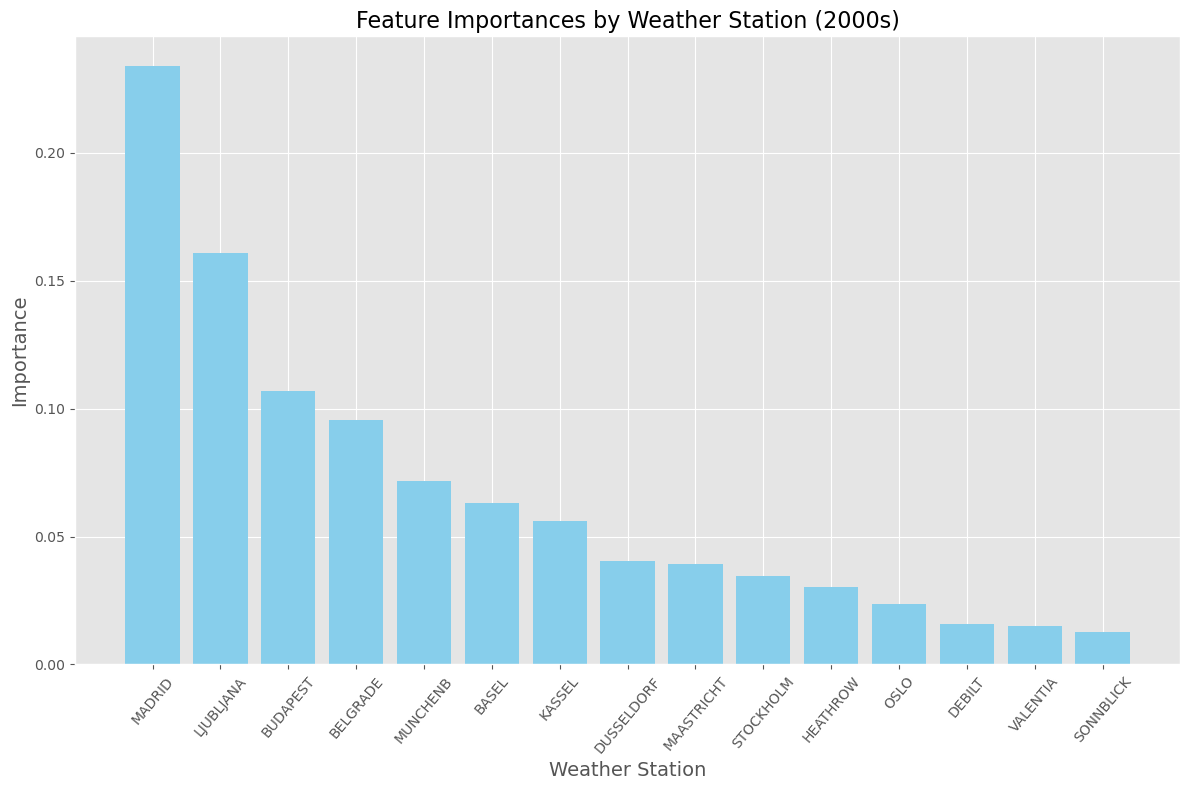

In [71]:
# Plotting the importances

plt.style.use('ggplot')
plt_2 = plt.figure(figsize=(12, 8))
plt.bar(collapsed_importances_df_2['Weather Station'], collapsed_importances_df_2['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Weather Station', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Feature Importances by Weather Station (2000s)', fontsize=16)
plt.tight_layout()
plt.show()

### 5. Top Three Weather Stations

#### Madrid

In [74]:
# Filtering weather dataset to only include Madrid
climatewins_madrid = climatewins_cleaned[climatewins_cleaned.columns[climatewins_cleaned.columns.astype(str).str.startswith('MADRID')]]

# Check output
climatewins_madrid.head()

,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max
0,6,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8
1,7,0.86,1.0254,0.46,0.0,0.9,9.8,7.4,12.2
2,5,0.90,1.0287,0.63,0.0,2.3,8.6,6.4,10.8
3,0,0.75,1.0281,1.16,0.0,8.7,10.3,4.5,16.1
4,2,0.64,1.0269,1.10,0.0,7.8,12.1,8.2,16.0


In [75]:
# Filter pleasant dataset to only include Madrid
pleasantweather_madrid = pleasantweather[pleasantweather.columns[pleasantweather.columns.astype(str).str.startswith('MADRID')]]

# Check output
pleasantweather_madrid.head()

,MADRID_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [76]:
# Check shape
print(climatewins_madrid.shape)
print(pleasantweather_madrid.shape)

(22950, 9)
(22950, 1)


In [77]:
# Create matrices
y_3 = pleasantweather_madrid.max(axis=1)

# Check shape
print("Shape of y_3_combined:", y_3.shape)

Shape of y_3_combined: (22950,)


In [78]:
# Check unique values in y_combined to ensure it's correct
print("Unique values in y_3_combined:", y_3.unique())

Unique values in y_3_combined: [0 1]


In [79]:
# Ensure y has the correct shape
y_3 = y_3.to_numpy().reshape(-1)

# Check shape
print(y_3.shape)

(22950,)


In [80]:
# Create X matrix
X_3 = climatewins_madrid.to_numpy()

# Check shapes of the matrices
print(X_3.shape)
print(y_3.shape)

(22950, 9)
(22950,)


In [81]:
# Split data into training and testing sets
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, random_state=127)

# Check shapes
print(X_train_3.shape, y_train_3.shape)
print(X_test_3.shape, y_test_3.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [82]:
# Creating a Random Forest classifier
clf_3 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_3.fit(X_train_3, y_train_3)

RandomForestClassifier(max_depth=3)

In [83]:
# Perform the predictions on the test dataset
y_pred_3 = clf_3.predict(X_test_3)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_3, y_pred_3))

Model Accuracy:  0.9900662251655629


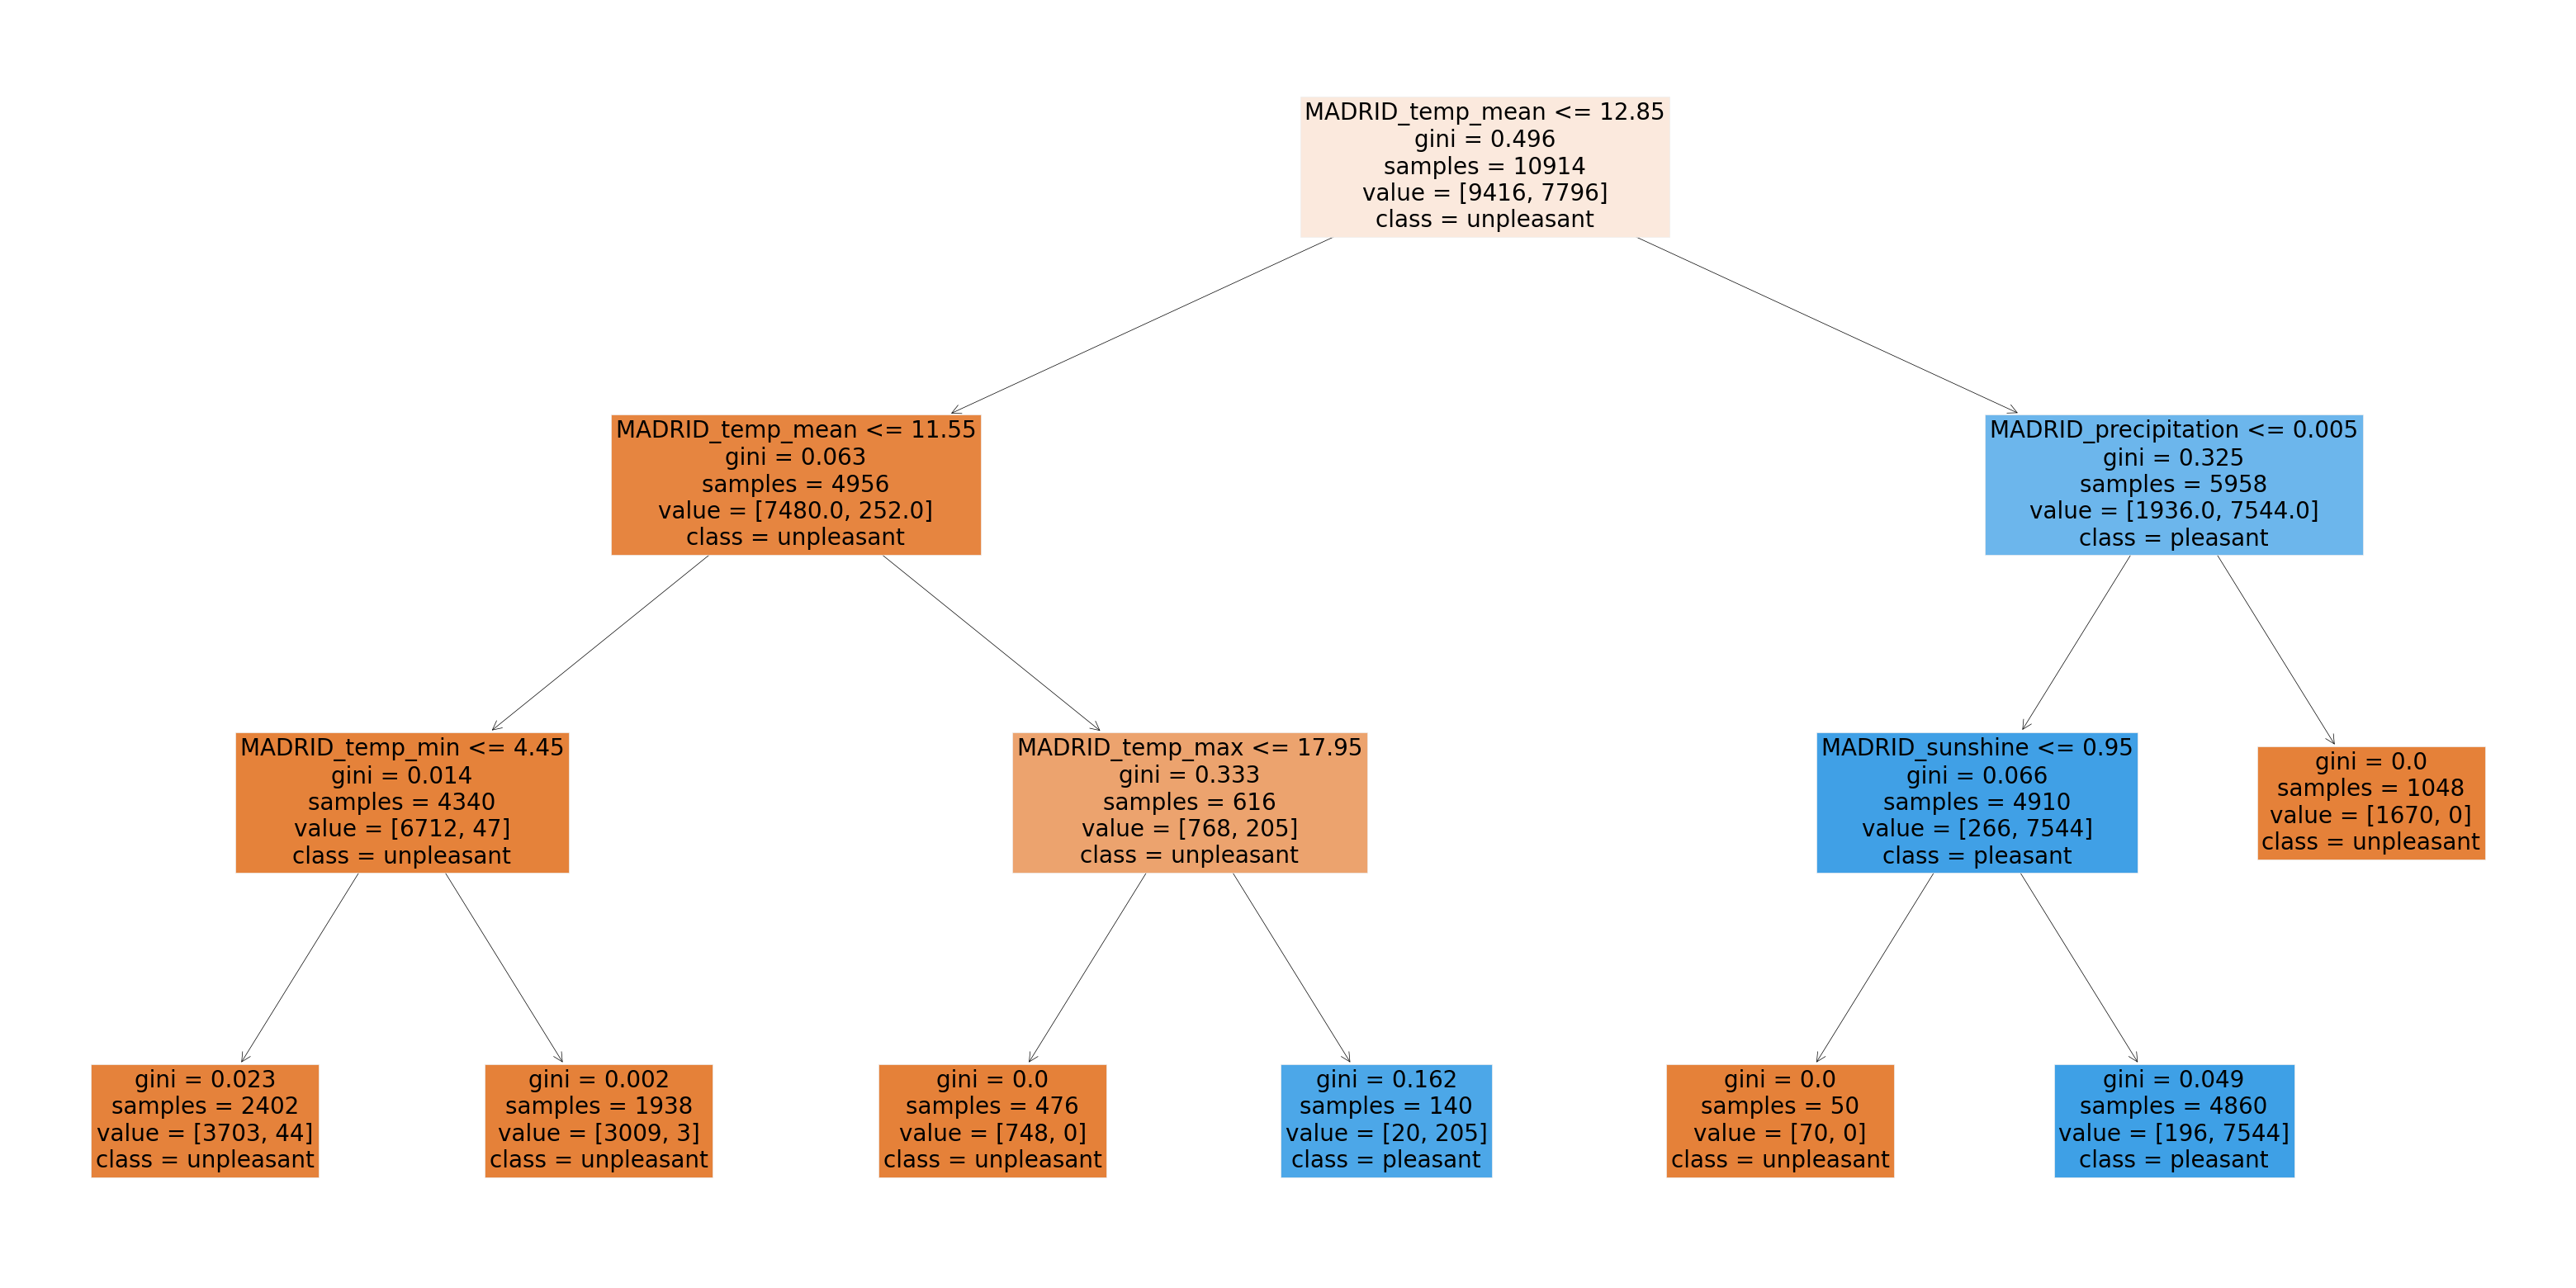

In [84]:
# Plot random forest (Madrid)
rf_3 = plt.figure(figsize=(40,20))
plot_tree(clf_3.estimators_[5], fontsize = 20, feature_names=climatewins_madrid.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [85]:
# Retrieve feature importances from the trained model
feature_importances_3 = clf_3.feature_importances_
print("Feature Importances:", feature_importances_3)
print(feature_importances_3.shape)

Feature Importances: [0.02027579 0.02965337 0.00081618 0.13012387 0.1225055  0.08121556
 0.23369575 0.05619708 0.32551689]
(9,)


In [86]:
# Create list for observation measurements
measurements = [
    'cloud_cover', 'humidity', 'pressure', 'global_radiation', 
    'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max'
]

In [87]:
# Create a dataframe to associate observation measurements with their importances
importances_df_3 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_3
})

In [88]:
# Sort by importance for chart readability
importances_df_3 = importances_df_3.sort_values(by='Importance', ascending=False)
print("Feature Importance:")
print(importances_df_3)

Feature Importance:
        Measurement  Importance
8          temp_max    0.325517
6         temp_mean    0.233696
3  global_radiation    0.130124
4     precipitation    0.122506
5          sunshine    0.081216
7          temp_min    0.056197
1          humidity    0.029653
0       cloud_cover    0.020276
2          pressure    0.000816


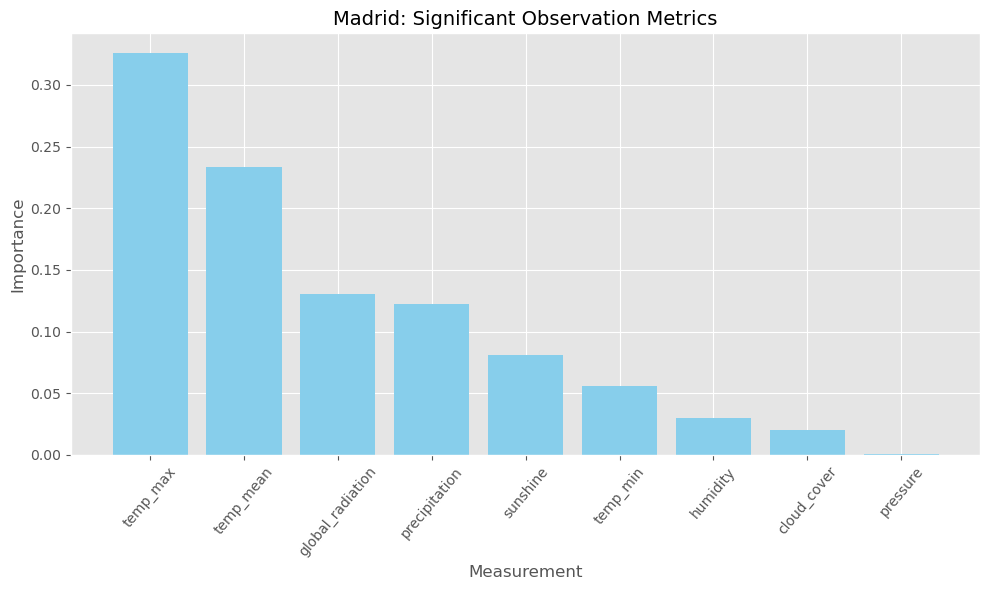

In [89]:
# Plot the importances

plt.style.use('ggplot')
plt_3 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_3['Measurement'], importances_df_3['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Madrid: Significant Observation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

#### Ljubljana

In [91]:
# Filter weather dataset to only include Budapest
climatewins_ljub = climatewins_cleaned[climatewins_cleaned.columns[climatewins_cleaned.columns.astype(str).str.startswith('LJUBLJANA')]]

# Check output
climatewins_ljub.head()

,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max
0,8,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5
1,6,0.94,1.0173,0.56,0.13,3.2,2.1,-1.3,5.5
2,8,0.96,1.0173,0.20,0.12,0.0,4.6,0.9,6.3
3,6,0.94,1.0173,0.49,0.00,2.2,3.2,1.0,7.0
4,7,0.94,1.0173,0.20,0.00,0.0,3.6,0.4,4.8


In [92]:
# Filter pleasant dataset to only include Ljubljana
pleasant_ljub = pleasantweather[pleasantweather.columns[pleasantweather.columns.astype(str).str.startswith('LJUBLJANA')]]

# Check output
pleasant_ljub.head()

,LJUBLJANA_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [93]:
# Check shape
print(climatewins_ljub.shape)
print(pleasant_ljub.shape)

(22950, 9)
(22950, 1)


In [94]:
# Create matrices
y_4 = pleasant_ljub.max(axis=1)

# Check shape
print("Shape of y_4_combined:", y_4.shape)

Shape of y_4_combined: (22950,)


In [95]:
# Check unique values in y_combined to ensure it's correct
print("Unique values in y_4_combined:", y_4.unique())

Unique values in y_4_combined: [0 1]


In [96]:
# Ensure y has the correct shape
y_4 = y_4.to_numpy().reshape(-1)

# Check shape
print(y_4.shape)

(22950,)


In [97]:
# Create X matrix
X_4 = climatewins_ljub.to_numpy()

# Check shapes of the matrices
print(X_4.shape)
print(y_4.shape)

(22950, 9)
(22950,)


In [98]:
# Split data into training and testing sets
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, random_state=127)

# Check shapes
print(X_train_4.shape, y_train_4.shape)
print(X_test_4.shape, y_test_4.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [99]:
# Creating a Random Forest classifier
clf_4 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_4.fit(X_train_4, y_train_4)

RandomForestClassifier(max_depth=3)

In [100]:
# Perform the predictions on the test dataset
y_pred_4 = clf_4.predict(X_test_4)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_4, y_pred_4))

Model Accuracy:  0.9972115719762984


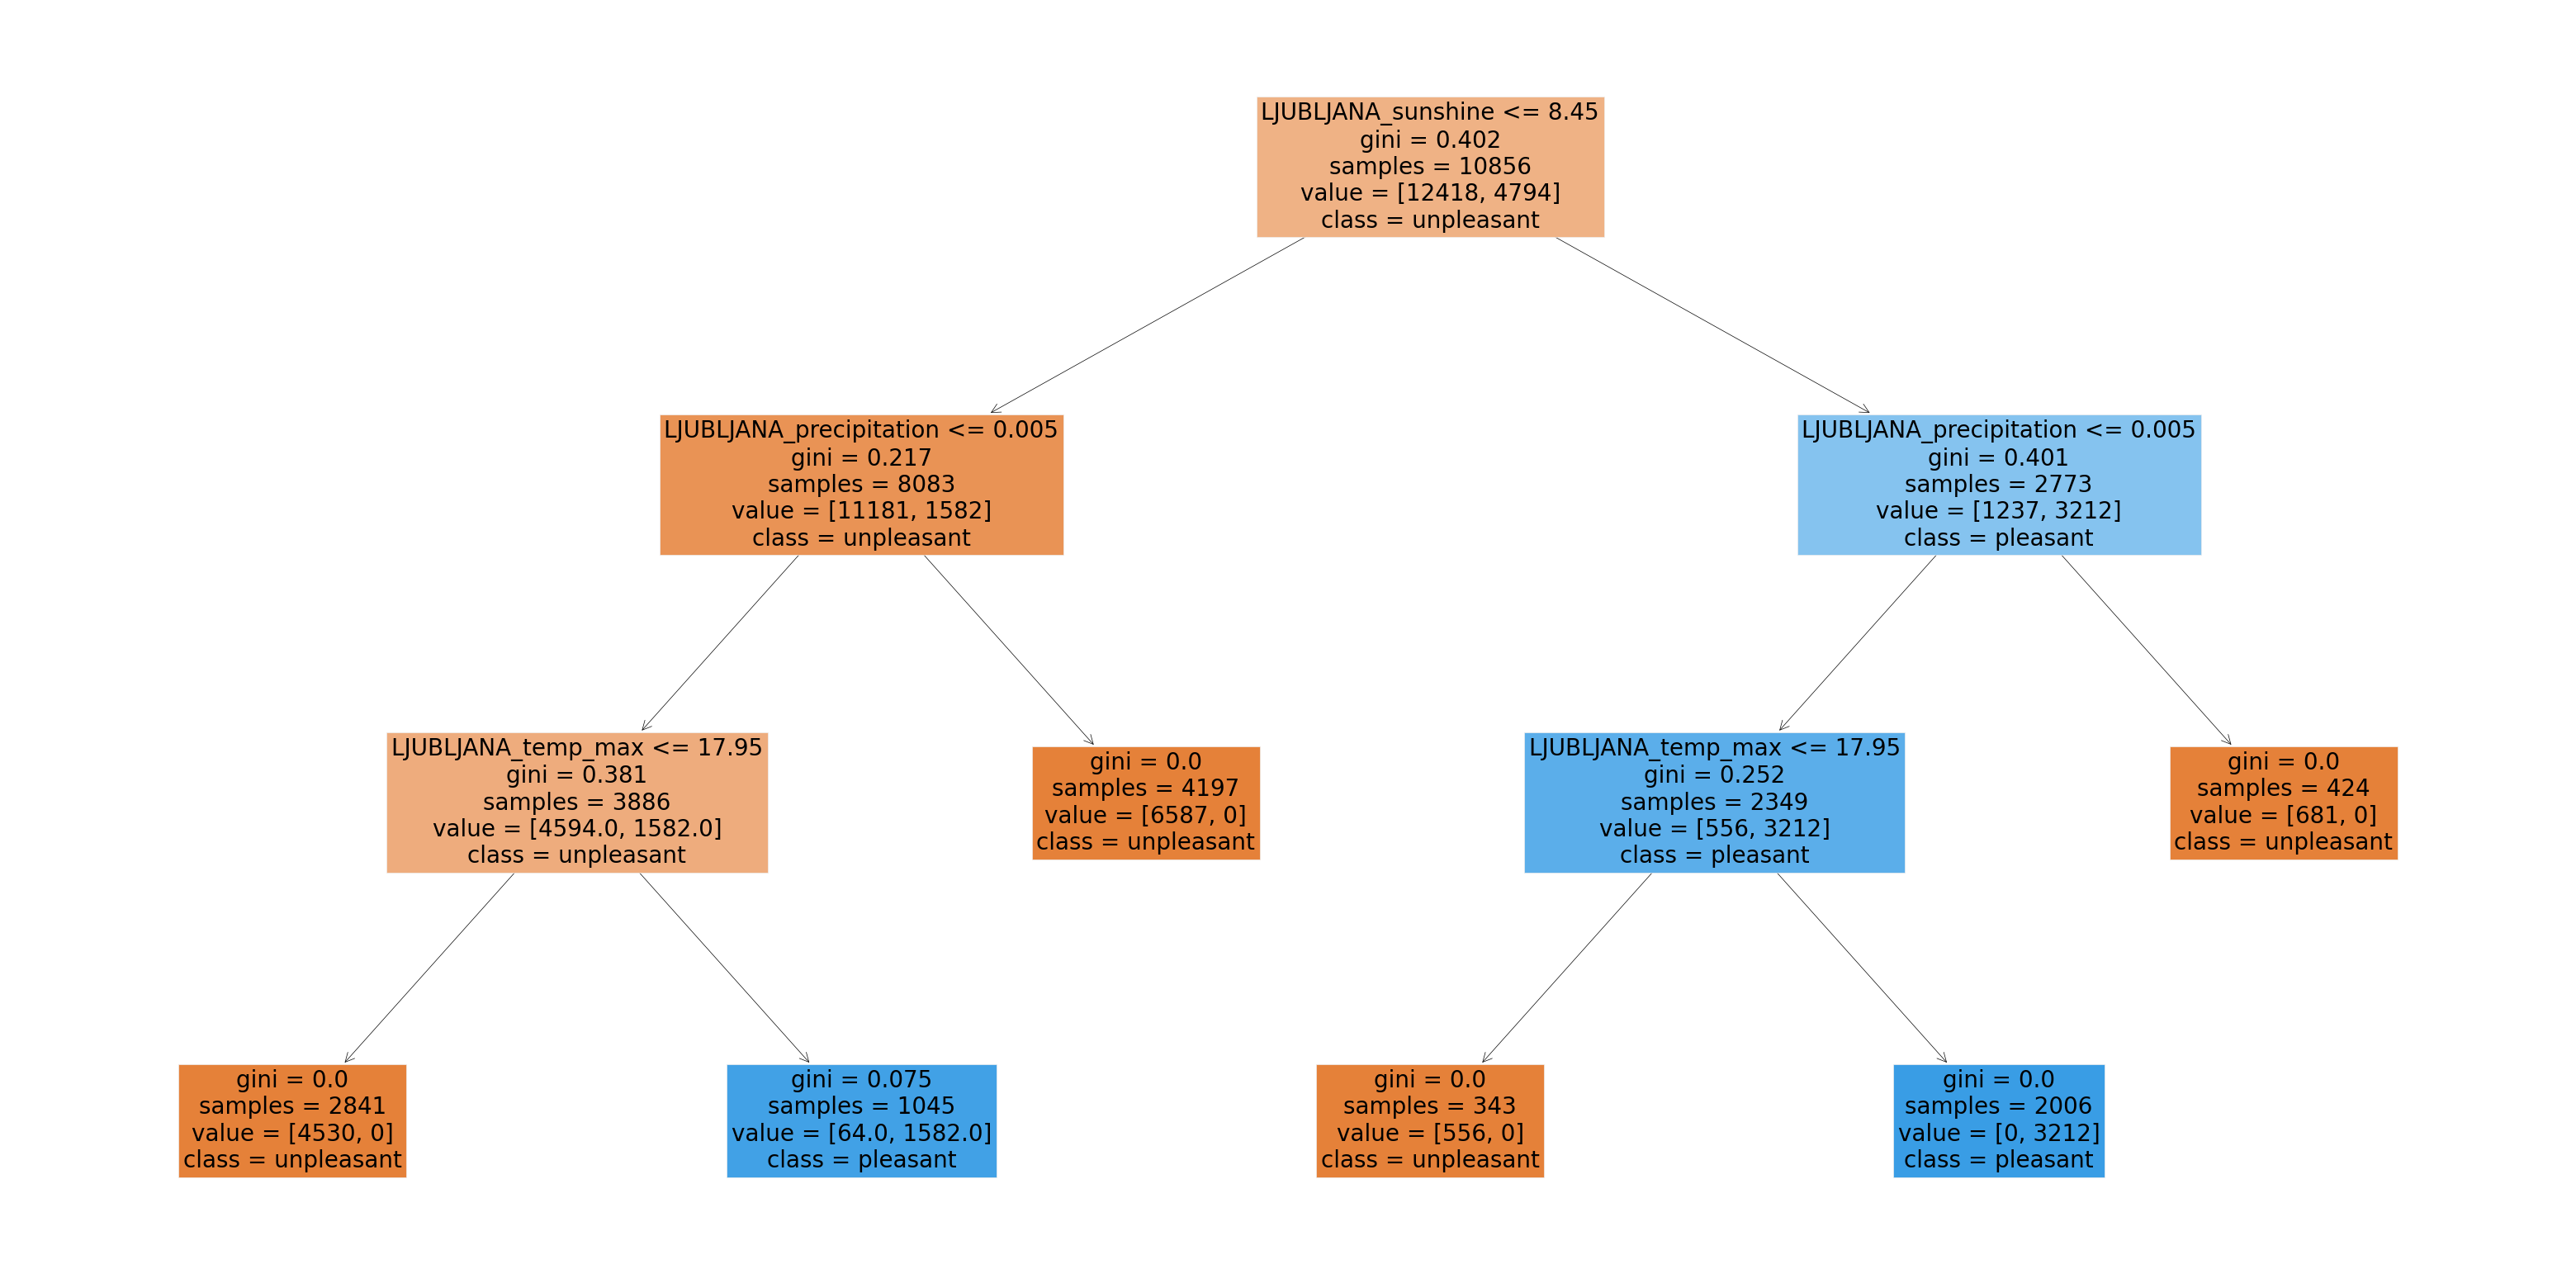

In [101]:
# Plotting random forest (Ljubljana)
rf_4 = plt.figure(figsize=(40,20))
plot_tree(clf_4.estimators_[5], fontsize = 20, feature_names=climatewins_ljub.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [102]:
# Retrieve feature importances from the trained model
feature_importances_4 = clf_4.feature_importances_
print("Feature Importances:", feature_importances_4)
print(feature_importances_4.shape)

Feature Importances: [0.04422547 0.01159629 0.00297157 0.15005433 0.26809302 0.12413322
 0.16090873 0.01399142 0.22402594]
(9,)


In [103]:
# Create a dataframe to associate observation measurements with their importances
importances_df_4 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_4
})

In [104]:
# Sort by importance for chart readability
importances_df_4= importances_df_4.sort_values(by='Importance', ascending=False)
print("Feature Importance:")
print(importances_df_4)

Feature Importance:
        Measurement  Importance
4     precipitation    0.268093
8          temp_max    0.224026
6         temp_mean    0.160909
3  global_radiation    0.150054
5          sunshine    0.124133
0       cloud_cover    0.044225
7          temp_min    0.013991
1          humidity    0.011596
2          pressure    0.002972


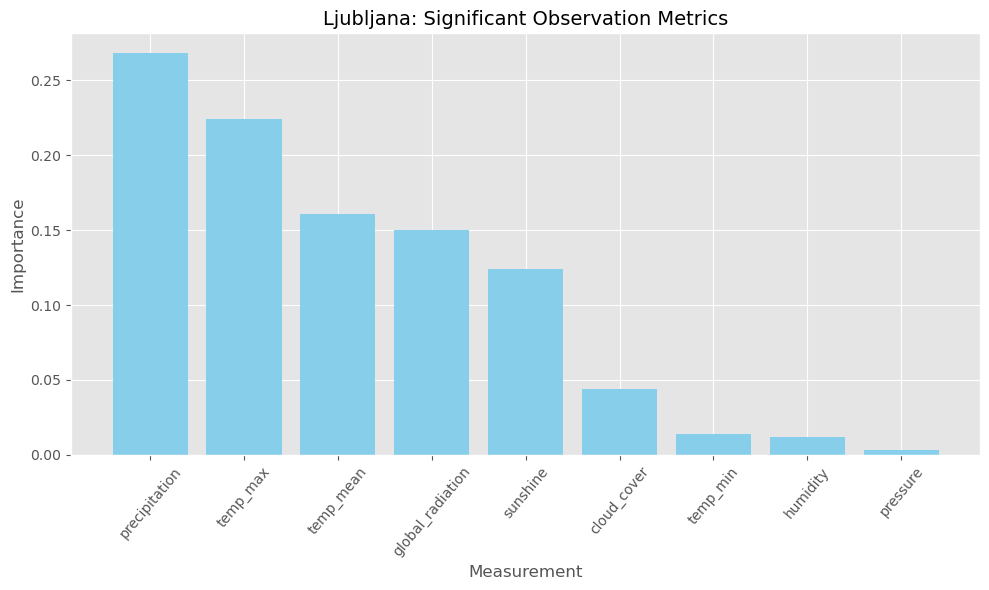

In [105]:
# Plotting the importances

plt.style.use('ggplot')
plt_4 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_4['Measurement'], importances_df_4['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Ljubljana: Significant Observation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

#### Budapest

In [107]:
# Filtering weather dataset to only include Budapest
climatewins_budapest = climatewins_cleaned[climatewins_cleaned.columns[climatewins_cleaned.columns.astype(str).str.startswith('BUDAPEST')]]

# Check output
climatewins_budapest.head()

,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max
0,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1
1,4,0.67,1.017,0.18,0.31,0.0,2.3,1.4,3.1
2,4,0.67,1.017,0.30,0.00,0.6,2.7,1.7,5.3
3,4,0.67,1.017,0.19,0.00,0.0,2.0,0.4,4.4
4,4,0.67,1.017,0.19,0.00,0.0,2.5,1.1,5.3


In [108]:
# Filtering pleasant dataset to only include Budapest
pleasantweather_budapest = pleasantweather[pleasantweather.columns[pleasantweather.columns.astype(str).str.startswith('BUDAPEST')]]

# Check output
pleasantweather_budapest.head()

,BUDAPEST_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [109]:
# Check shape
print(climatewins_budapest.shape)
print(pleasantweather_budapest.shape)

(22950, 9)
(22950, 1)


In [110]:
# Creating matrices
y_5 = pleasantweather_budapest.max(axis=1)

# Check shape
print("Shape of y_5_combined:", y_5.shape)

Shape of y_5_combined: (22950,)


In [111]:
# Check unique values in y_combined to ensure it's correct
print("Unique values in y_5_combined:", y_5.unique())

Unique values in y_5_combined: [0 1]


In [112]:
# Ensure y has the correct shape
y_5 = y_5.to_numpy().reshape(-1)

# Check shape
print(y_5.shape)

(22950,)


In [113]:
# Create X matrix
X_5 = climatewins_budapest.to_numpy()

# Check shapes of the matrices
print(X_5.shape)
print(y_5.shape)

(22950, 9)
(22950,)


In [114]:
# Split data into training and testing sets
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, random_state=127)

# Check shapes
print(X_train_5.shape, y_train_5.shape)
print(X_test_5.shape, y_test_5.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [115]:
# Creating a Random Forest classifier
clf_5 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_5.fit(X_train_5, y_train_5)

RandomForestClassifier(max_depth=3)

In [116]:
# Perform the predictions on the test dataset
y_pred_5 = clf_5.predict(X_test_5)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_5, y_pred_5))

Model Accuracy:  0.9973858487277797


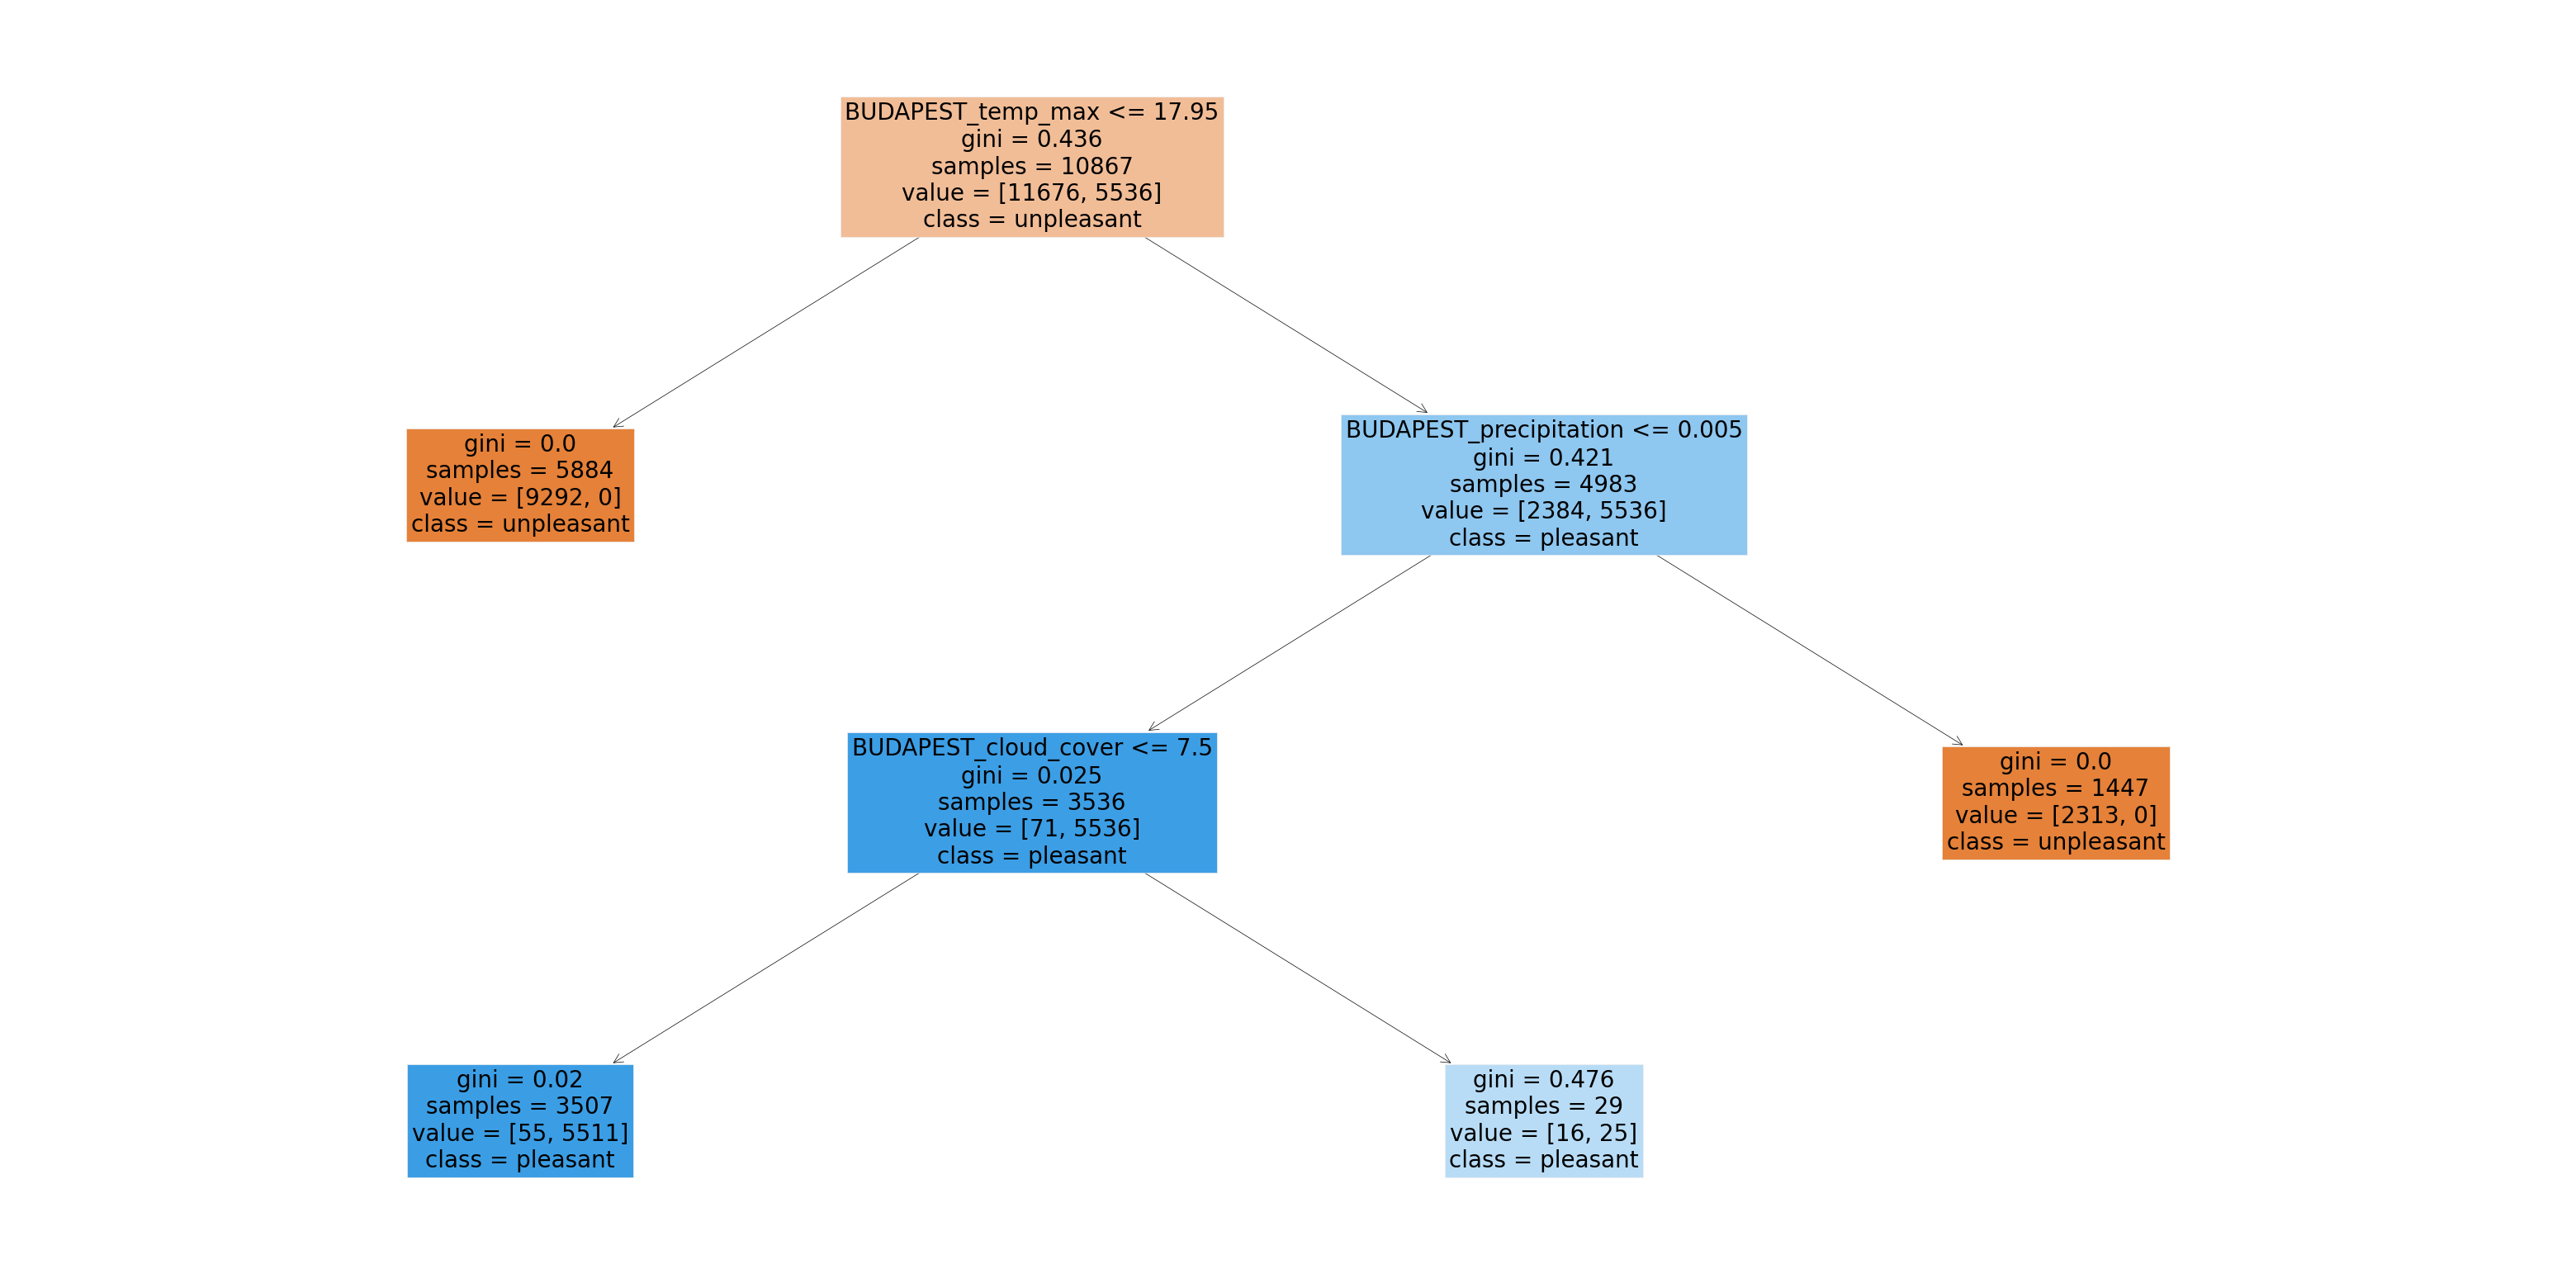

In [117]:
# Plot random forest (Budapest)
rf_5 = plt.figure(figsize=(40,20))
plot_tree(clf_5.estimators_[5], fontsize = 20, feature_names=climatewins_budapest.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [118]:
# Retrieve feature importances from the trained model
feature_importances_5 = clf_5.feature_importances_
print("Feature Importances:", feature_importances_5)
print(feature_importances_5.shape)

Feature Importances: [0.0138825  0.00682365 0.00065757 0.05076517 0.28347427 0.04869355
 0.20845584 0.08685447 0.30039298]
(9,)


In [119]:
# Create a dataframe to associate observation measurements with their importances
importances_df_5 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_5
})

In [120]:
# Sort by importance for chart readability
importances_df_5 = importances_df_5.sort_values(by='Importance', ascending=False)
print("Feature Importance:")
print(importances_df_5)

Feature Importance:
        Measurement  Importance
8          temp_max    0.300393
4     precipitation    0.283474
6         temp_mean    0.208456
7          temp_min    0.086854
3  global_radiation    0.050765
5          sunshine    0.048694
0       cloud_cover    0.013883
1          humidity    0.006824
2          pressure    0.000658


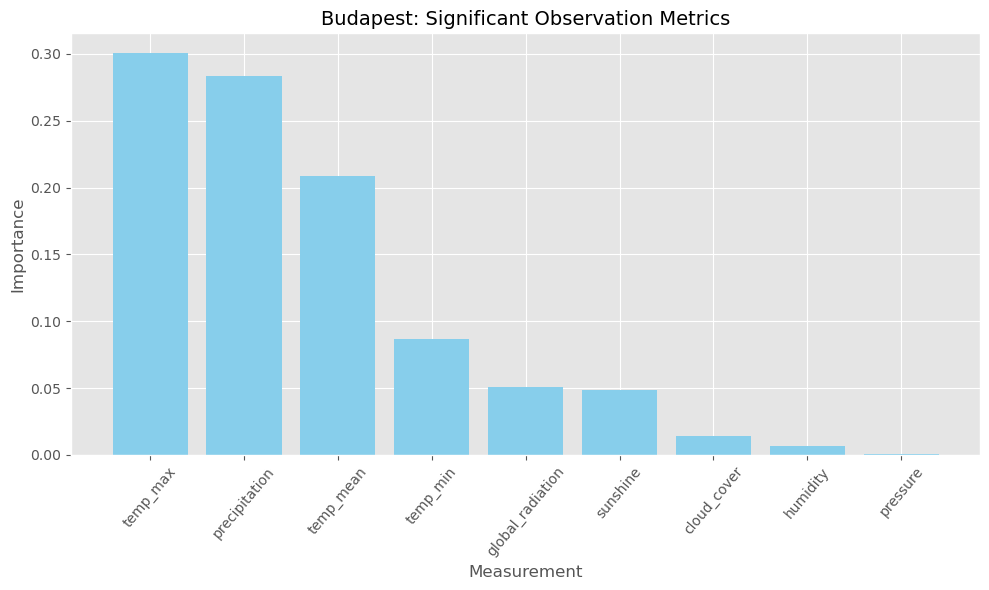

In [121]:
# Plot the importances

plt.style.use('ggplot')
plt_5 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_5['Measurement'], importances_df_5['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Budapest: Significant Observation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

#### Kassel

In [230]:
# Filtering weather dataset to only include Kassel
climatewins_kassel = climatewins_cleaned[climatewins_cleaned.columns[climatewins_cleaned.columns.astype(str).str.startswith('KASSEL')]]

# Check output
climatewins_kassel.head()

,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max
0,8.0,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4
1,6.0,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1
2,8.0,0.91,1.0129,0.12,0.60,0.0,6.5,6.0,8.0
3,6.0,0.87,1.0290,0.12,0.00,0.0,5.8,5.2,6.5
4,7.0,0.86,1.0262,0.13,0.71,0.0,5.4,3.7,6.0


In [232]:
# Filtering pleasant dataset to only include Kassel
pleasantweather_kassel = pleasantweather[pleasantweather.columns[pleasantweather.columns.astype(str).str.startswith('KASSEL')]]

# Check output
pleasantweather_kassel.head()

,KASSEL_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [234]:
# Check shape
print(climatewins_kassel.shape)
print(pleasantweather_kassel.shape)

(22950, 9)
(22950, 1)


In [236]:
# Creating matrices
y_6 = pleasantweather_kassel.max(axis=1)

# Check shape
print("Shape of y_6_combined:", y_6.shape)

Shape of y_6_combined: (22950,)


In [238]:
# Check unique values in y_combined to ensure it's correct
print("Unique values in y_6_combined:", y_6.unique())

Unique values in y_6_combined: [0 1]


In [240]:
# Ensure y has the correct shape
y_6 = y_6.to_numpy().reshape(-1)

# Check shape
print(y_6.shape)

(22950,)


In [242]:
# Create X matrix
X_6 = climatewins_kassel.to_numpy()

# Check shapes of the matrices
print(X_6.shape)
print(y_6.shape)

(22950, 9)
(22950,)


In [246]:
# Split data into training and testing sets
X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X_6, y_6, random_state=127)

# Check shapes
print(X_train_6.shape, y_train_6.shape)
print(X_test_6.shape, y_test_6.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [248]:
# Creating a Random Forest classifier
clf_6 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf_6.fit(X_train_6, y_train_6)

RandomForestClassifier(max_depth=3)

In [250]:
# Perform the predictions on the test dataset
y_pred_6 = clf_6.predict(X_test_6)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test_6, y_pred_6))

Model Accuracy:  0.9945974207040781


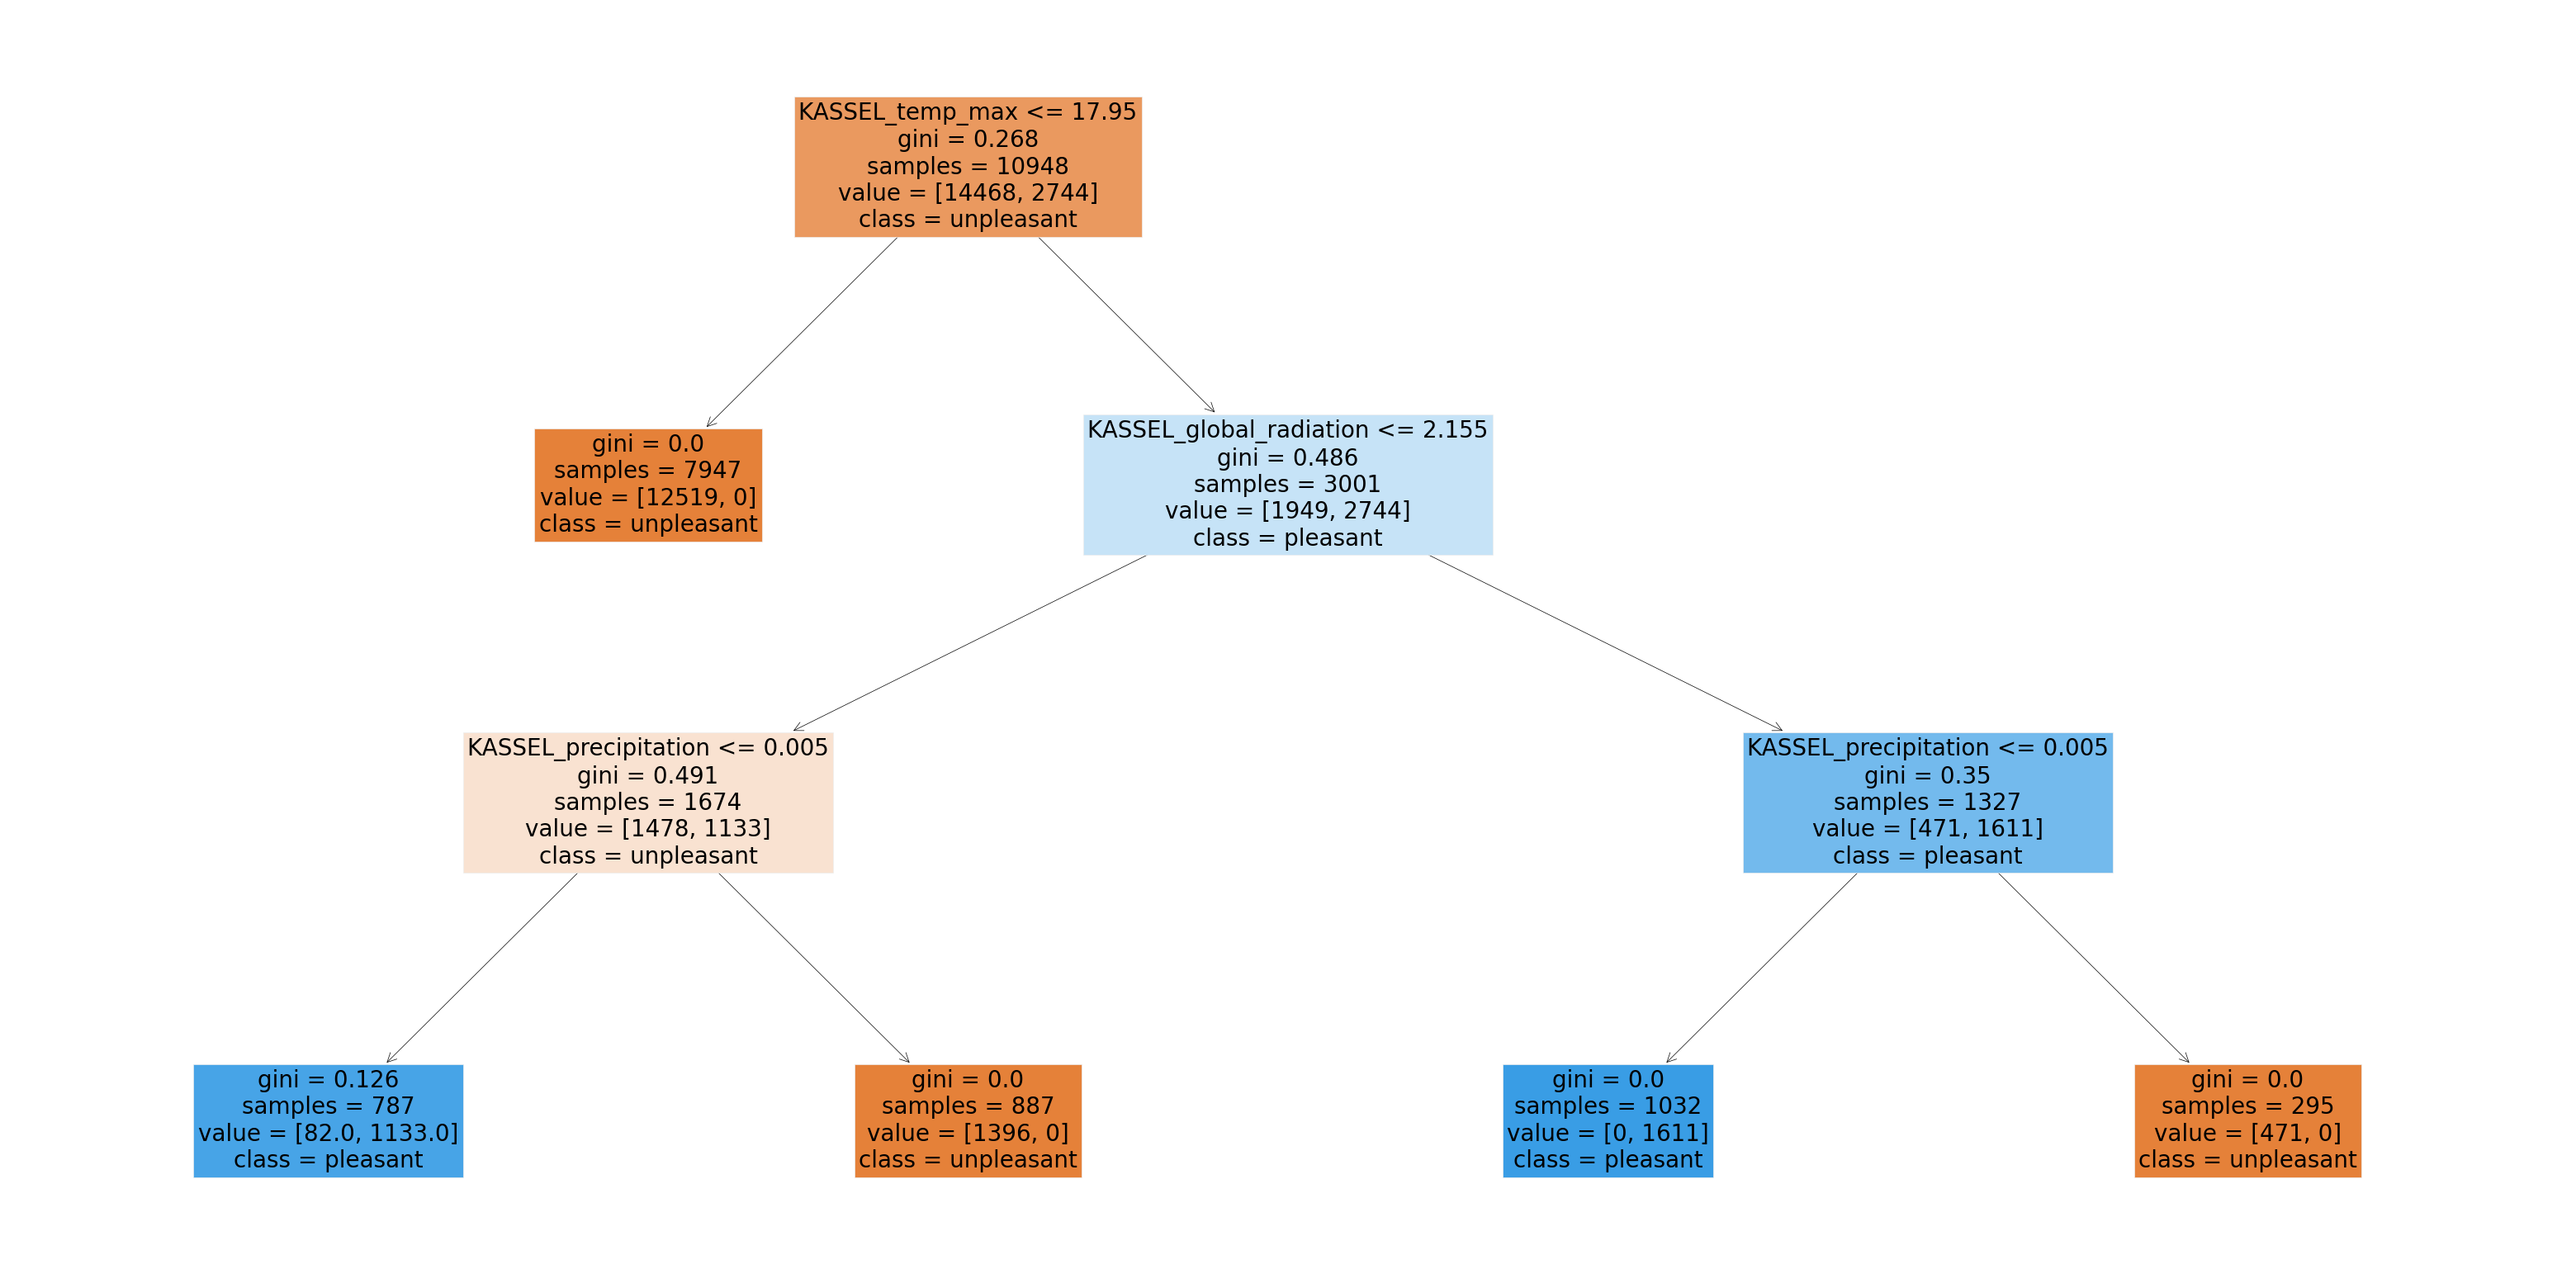

In [260]:
# Plot random forest (Kassel)
rf_6 = plt.figure(figsize=(40,20))
plot_tree(clf_6.estimators_[5], fontsize = 20, feature_names=climatewins_kassel.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [254]:
# Retrieve feature importances from the trained model
feature_importances_6 = clf_6.feature_importances_
print("Feature Importances:", feature_importances_6)
print(feature_importances_6.shape)

Feature Importances: [0.         0.03334451 0.00721276 0.10350405 0.25410315 0.10059946
 0.19660212 0.03852366 0.26611029]
(9,)


In [256]:
# Create a dataframe to associate observation measurements with their importances
importances_df_6 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_6
})

In [258]:
# Sort by importance for chart readability
importances_df_6 = importances_df_6.sort_values(by='Importance', ascending=False)
print("Feature Importance:")
print(importances_df_6)

Feature Importance:
        Measurement  Importance
8          temp_max    0.266110
4     precipitation    0.254103
6         temp_mean    0.196602
3  global_radiation    0.103504
5          sunshine    0.100599
7          temp_min    0.038524
1          humidity    0.033345
2          pressure    0.007213
0       cloud_cover    0.000000


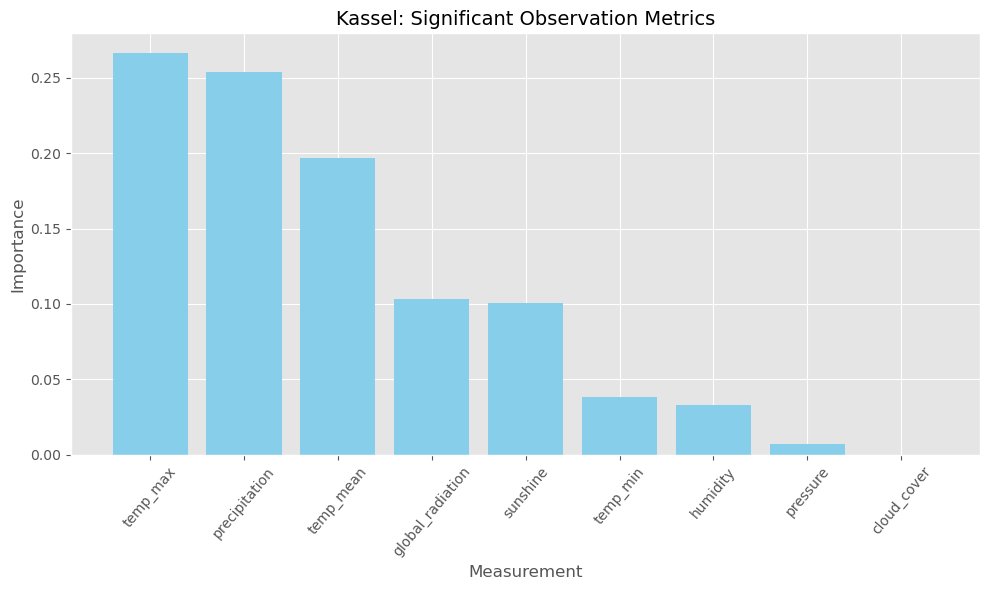

In [262]:
# Plot the importances

plt.style.use('ggplot')
plt_6 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_6['Measurement'], importances_df_6['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Kassel: Significant Observation Metrics", fontsize=14)
plt.tight_layout()
plt.show()